# SynBIC Bioinformatics Seminar: Introduction to PCA, Clustering and Data Analysis, Part 2

___

#### Overview and Motivation

We have previously covered PCA as a linear transform to map data in a way that captures the most variation in a dataset. From the Iris dataset, we could identify a clear separation of the datapoints into (at least) two groups. In an attempt to classify these points into **classes**, a number of different clustering approaches may be employed.


___

#### Summary of this notebook
- Introduction to the need for clustering.
- Supervised vs unsupervised methods.
- K-means, Gaussian Mixture Models, Leiden and HDBSCAN methods of clustering.
- Variability in a method due to randomness.
- The effect of separated vs continuous manifolds.

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#### sets format of plots to SVG, just a personal preference for better quality plots
%config InlineBackend.figure_format = 'svg'

#### Continuing from last time...
___


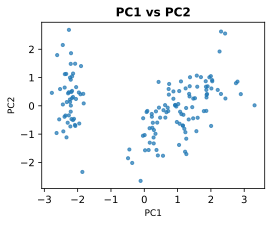

In [2]:
#### Quickly replicate the workflow from notebook 00

iris_df = pd.DataFrame(data=load_iris().data, columns=load_iris().feature_names)

scaled_data = StandardScaler().fit_transform(iris_df)
iris_model = PCA().fit(scaled_data)
iris_pca_df = iris_model.transform(scaled_data)
iris_pca_df = pd.DataFrame(
    iris_pca_df,
    columns=[f"PC{i+1}" for i in range(iris_pca_df.shape[1])]
)

#### Plot PC1 vs PC2 as a scatter plot

plt.figure(figsize=(4, 3))
plt.scatter(
    iris_pca_df['PC1'],
    iris_pca_df['PC2'],
    s=10,
    alpha=0.7
)
plt.xlabel('PC1', fontsize=9)
plt.ylabel('PC2', fontsize=9)
plt.title('PC1 vs PC2', fontsize=12, fontweight='bold')
plt.show()


#### The need for clustering
___
As mentioned at the end of the previous notebook, the PCA technique is often used to reveal distributions that are not particularly obvious just by looked at feature relations in the raw data. From the plot above, we can clearly see the datapoints partition themselves into two clear groups, indicating at least two **classes** (classifications) of the data can rationally be inferred. Since this is a toy dataset, one only needs to visit the [Iris Dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris) from sklearn to see the true number of classes. In reality, we often do not have this luxury with data measurements. This uncertainty motivates a need for effective clustering techniques in order to best classify nature, though the philosophical debate of whether the human nature of desiring to discretely classify everything it sees is rational is beyond the scope of this workshop ;).

#### Quick briefing on supervised and unsupervised methods
___
It is important to understand that everything that has been covered thus far falls into the domain of machine learning. Clustering methods are no different. At a fundamental level, the difference between supervised and unsupervised methods stems from whether the model relies on a pre-labelled training data or well-defined answers. Whilst some supervised clustering algorithms do exist, the most commonly used ones are unsupervised, and are the focus of this workshop.

The clustering methods taught here are summarised below:
- k-means.
- Gaussian Misture Models (GMM).
- Leiden clustering.
- Hierarchical Density-Based Spatial Clustering of Applications with Noise (HDBSCAN).

#### k-means
___
k-means is one of the simplest clustering algorithms out there and works as this:
1) user manually chooses *k* random points to be centroids (the middle of the cluster).
2) assign every point in the dataset to its closest centroid.
3) Recalculate the each centroid as the mean of the points in the corresponding cluster.
4) Re-iterate until convergence.

c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


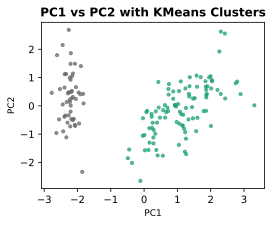

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,   # choose the number of clusters you want to find.
    random_state=1  # setting the random state ensures that results are reproducible.
    )

labels = kmeans.fit_predict(iris_pca_df)

plt.figure(figsize=(4, 3))
plt.scatter(
    iris_pca_df['PC1'],
    iris_pca_df['PC2'],
    c=labels,
    cmap='Dark2',
    s=10,
    alpha=0.7
)
plt.xlabel('PC1', fontsize=9)
plt.ylabel('PC2', fontsize=9)
plt.title('PC1 vs PC2 with KMeans Clusters', fontsize=12, fontweight='bold')
plt.show()

<details>
<summary>The above plot shows the now-labelled data after a k-means algorithm has been implemented. However, there is a pretty clear drawback to k-means. Can you think of what it is?</summary>

One needs to manually choose the number of clusters (*k*) for this algorithm. This can be problematic as it relies on the user rationally choosing a good number, and it is a drawback not unique to k-means. Obviously, good scientists don't choose this number arbitrarily if they decide to take this approach, and use a number of different criterions and metrics to guide and justify their selection of *k*.

Here we focus on the two most standard ones, which complement each other. These are the **Elbow Method** and the **Silhouette Score**.

Let us trial three different values of *k*: 2, 3 and 4.
</details>

#### The Silhouette Score

The Silhouette Score is calculated as so: if we let *a* be the mean intra-cluster distance and *b* is the mean nearest-cluster distance for a single data point, then the Silhouette Coefficient is:

```math
(a-b) / max(a,b)
```

Such that values are constrained between 1 (best outcome) and -1 (worst outcome). Values near 0 indicate overlapping clusters. Negative values generally indicate that a sample has been assigned to the wrong cluster, as a different cluster is more similar.

In [5]:
from sklearn.metrics import silhouette_score

trialled_ks = [2, 3, 4]

for n_clusters in trialled_ks:
    labels = KMeans(
        n_clusters=n_clusters, 
        random_state=1
        ).fit_predict(iris_pca_df)
    silhouette_avg = silhouette_score(iris_pca_df, labels)
    print(f'Silhouette Score for {n_clusters} clusters: {silhouette_avg:.2f}')


c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhouette Score for 2 clusters: 0.58
Silhouette Score for 3 clusters: 0.46
Silhouette Score for 4 clusters: 0.42


c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


#### The Elbow Method

The Elbow Method helps choose the number of clusters *k*. We plot the **within-cluster variance** using the **WCSS metric** (Within-Cluster Sum of Squares), sometimes also called intertia. The user picks the "elbow point" which corresponds to where adding more clusters has a marginal reduction effect on WCSS.

c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak o

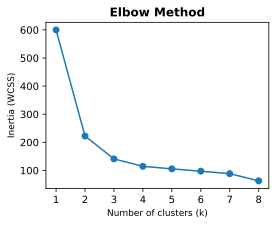

In [6]:
trialled_ks = range(1, 9)
inertias = [KMeans(n_clusters=k, random_state=1).fit(iris_pca_df).inertia_ for k in trialled_ks]

plt.figure(figsize=(4, 3))
plt.plot(trialled_ks, inertias, marker='o')
plt.xticks(trialled_ks)
plt.xlabel('Number of clusters (k)', fontsize=9)
plt.ylabel('Inertia (WCSS)', fontsize=9)
plt.title('Elbow Method', fontsize=12, fontweight='bold')
plt.show()

To finish off this section on k-means, let us properly conclude what the Silhouette Score and Elbow Plots achieve, for they are different but complementary methods and by no means alternatives over each other. The Silhouette Score is a validation measure for good clustering, calculated from the comparison of mean within-cluster distance against mean outside-cluster distance. The Elbow Method is simply a decision rule for initialising *k*. Finally, one must recognise that these are mere tools for helping the user achieve a more confident decision, but remain crude in their approach.

#### Gaussian Mixture Models
___
1. Choose a number of clusters, and initialise each cluster as a Gaussian distribution with its own mean and variance.
2. For every data point, compute the probability of belonging to each Gaussian.
3. Update each Gaussian's parameters to better fit the data.
4. Reiterate until convergence.

Similar idea to k-means, but GMM: (1) can model clusters with different shapes; and (2) returns probabilities of belonging to each cluster rather than a single fixed assignment.

c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


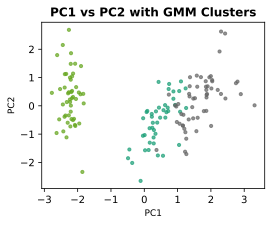

In [13]:
#### Choosing 3 clusters for GMM here to showcase how the clusters may look like

from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=6)
labels = gmm.fit_predict(iris_pca_df)

plt.figure(figsize=(4, 3))
plt.scatter(
    iris_pca_df['PC1'],
    iris_pca_df['PC2'],
    c=labels,
    cmap='Dark2',
    s=10,
    alpha=0.7
)
plt.xlabel('PC1', fontsize=9)
plt.ylabel('PC2', fontsize=9)
plt.title('PC1 vs PC2 with GMM Clusters', fontsize=12, fontweight='bold')
plt.show()

There are three common criterions for optimising the number of components in GMM clustering: (1) Akaike Information Criterion; (2) Bayesian Information Criterion; and (3) Silhouette Score, which has already been covered.

#### Akaike Information Criterion (AIC)

The **Akaike Information Criterion (AIC)** is a way of judging how goodness of fit of a model whilst also penalising it for being too complicated. Intuitively, it asks:

> “Does the improvement in fit justify the extra parameters I have added?”

Mathematically, AIC can be written as:

$$
\mathrm{AIC} = 2k - 2\ln(L)
$$

where:
- *k* is the number of model parameters
- *L* is the likelihood of the model fitting the data

A **lower AIC** suggests a better balance between fit and complexity. Looking at the equation, the first term penalises complexity based on how many model parameters are used, whilst the second term rewards a model that fits the data well.


c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak o

Best number of components by AIC: 7


c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


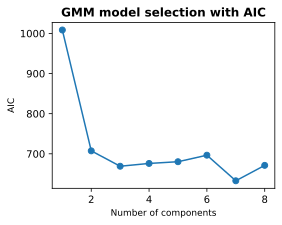

In [11]:
#### AIC sweep for GMM on Iris with num components from 1 to 8
import numpy as np
from sklearn.mixture import GaussianMixture

n_components_range = range(1, 9)
aic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=6)
    gmm.fit(iris_pca_df)
    aic_scores.append(gmm.aic(iris_pca_df))

best_n = n_components_range[int(np.argmin(aic_scores))]
print(f"Best number of components by AIC: {best_n}")

plt.figure(figsize=(4, 3))
plt.plot(n_components_range, aic_scores, marker='o')
plt.xlabel('Number of components', fontsize=9)
plt.ylabel('AIC', fontsize=9)
plt.title('GMM model selection with AIC', fontsize=12, fontweight='bold')
plt.show()

#### Bayesian Information Criterion (BIC)

The **Bayesian Information Criterion (BIC)** is similar in spirit to the AIC, but it penalises model complexity more strongly, especially when the dataset is large. It can be written as:

$$
\mathrm{BIC} = k\ln(n) - 2\ln(L)
$$

where:
- *n* is the number of data points
- *k* is the number of model parameters
- *L* is the likelihood of the model fitting the data

Here, a **lower BIC value** also suggests a better balance between goodness of fit and complexity. Because *ln(n)* usually grows larger than 2 for real datasets, BIC tends to favour **simpler models** than AIC.


c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak o

Best number of components by BIC: 2


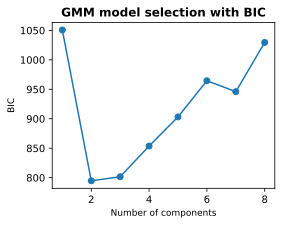

In [ ]:
#### BIC sweep for GMM on Iris with num components from 1 to 8
import numpy as np
from sklearn.mixture import GaussianMixture

n_components_range = range(1, 9)
bic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=6)
    gmm.fit(iris_pca_df)
    bic_scores.append(gmm.bic(iris_pca_df))

best_n = n_components_range[int(np.argmin(bic_scores))]
print(f"Best number of components by BIC: {best_n}")

plt.figure(figsize=(4, 3))
plt.plot(n_components_range, bic_scores, marker='o')
plt.xlabel('Number of components', fontsize=9)
plt.ylabel('BIC', fontsize=9)
plt.title('GMM model selection with BIC', fontsize=12, fontweight='bold')
plt.show()

In summary, BIC and AIC are very similar criterions regarding what they are achieving to achieve, but BIC favours simpler models whilst AIC is more lenient towards complex ones. Ultimately, it is up to the user to decide on a good number of components based on the information provided by these criterions.

**From the BIC and AIC sweeps performed above, what do you think is a good number of components to go for?**

#### Leiden clustering
___

**Leiden clustering** is a graph-based method for identifying groups of similar data points. Rather than drawing clusters directly in the original feature space, it first represents the dataset as a **nearest-neighbour graph**:

- each data point becomes a **node**
- edges connect points that are considered close or similar

The goal is then to divide this graph into **communities** such that points within the same cluster are more strongly connected to one another than to points in other clusters.

Intuitively, the method asks:

> “Can I partition this network so that strongly connected points stay together, while weakly connected points are separated?”

This is usually done by optimising a quality function, called **modularity** or a closely related objective. The quality function rewards cluster assignments where there are many connections within clusters and relatively few between them.


#### Why Leiden is useful

Leiden clustering is widely used because it tends to produce clusters that are **better connected and more stable** than older graph-based methods such as Louvain clustering, on which it is based (see article [here](https://www.nature.com/articles/s41598-019-41695-z) for more info). In particular, Leiden improves the partition iteratively so that clusters are not only high-scoring according to the quality function, but also internally well connected.

For high-dimensional biological data, this is very useful because we often begin by building a neighbourhood graph from PCA coordinates or another low-dimensional representation. Importantly, Leiden clustering does not make assumptions about spherical clusters or linearity.

#### Parameters for implementation

There are two main parameters for Leiden: (1) the degree of connections per node *k*, which determins how local or global structures in the network would be; and the resolution paramater *res*, which dictates how "coarse" clusters are by penalising small communities to different degrees

Number of Leiden clusters: 6


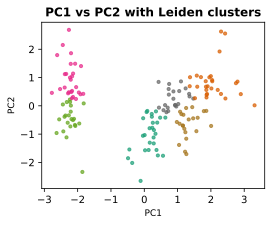

In [12]:
#### Leiden clustering on Iris first 2 PCs
# %pip -q install python-igraph leidenalg  ###  remove this later

import numpy as np
from sklearn.neighbors import kneighbors_graph
import igraph as ig
import leidenalg

# Build an undirected kNN graph from PC1/PC2
A = kneighbors_graph(
    iris_pca_df[['PC1', 'PC2']],
    n_neighbors=20,
    mode='connectivity',
    include_self=False
    )
A = A.maximum(A.T)

edges = list(zip(*A.nonzero()))
graph = ig.Graph(n=A.shape[0], edges=edges, directed=False)
graph.simplify()

partition = leidenalg.find_partition(
    graph,
    leidenalg.RBConfigurationVertexPartition,
    resolution_parameter=1.0,
    seed=1
    )
leiden_labels = np.array(partition.membership)

print(f'Number of Leiden clusters: {len(np.unique(leiden_labels))}')

plt.figure(figsize=(4, 3))
plt.scatter(
    iris_pca_df['PC1'],
    iris_pca_df['PC2'],
    c=leiden_labels,
    cmap='Dark2',
    s=10,
    alpha=0.7
    )
plt.xlabel('PC1', fontsize=9)
plt.ylabel('PC2', fontsize=9)
plt.title('PC1 vs PC2 with Leiden clusters', fontsize=12, fontweight='bold')
plt.show()

This result is drastically different from the k-means and GMM. Whilst we don't need to manually choose the number of clusters for Leiden, the outcome of the algorithm is very sensitive to the choice of *k* and *res* parameters.

There are many ways of evaluating the goodness of fit for these parameters, but typically, most people look at modularity and the silhouette score for guidance.

#### Modularity of clusters

The modularity of clusters is a measure of how "pure" clusters are, or how well separated they may be. In essence, a pair of clusters that mix heavily would have a low modularity score. The Leiden model has a built-in modularity method which simply returns the average modularity across all pairs of clusters in the system.

Modularity typically ranges between -0.5 and 1. A positive score means there is some degree of separation between clusters; a score of 0 indicates that the structure of clusters is no better than a random graph; a negative score means the data points in clusters are less likely to occur than by random chance.

,k,resolution,n_clusters,modularity,silhouette
0,5,0.25,6,7.745107e-01,0.390962
1,5,0.50,8,8.113001e-01,0.395219
2,5,0.75,8,8.113001e-01,0.395219
3,5,1.00,8,8.120410e-01,0.408484
4,10,0.25,4,6.370477e-01,0.432239
5,10,0.50,5,7.176781e-01,0.398399
6,10,0.75,6,7.316945e-01,0.418425
7,10,1.00,8,7.351983e-01,0.389839
8,15,0.25,2,4.415584e-01,0.614520
9,15,0.50,4,6.196869e-01,0.434919


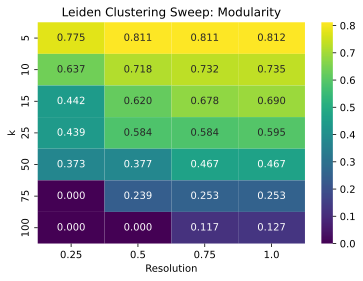

In [23]:
#### Sweep Leiden parameters k and res to find best modularity score
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import silhouette_score
import seaborn as sns

k_values = [5, 10, 15, 25, 50, 75, 100]
res_values = [0.25, 0.5, 0.75, 1.0]
X = iris_pca_df[['PC1', 'PC2']].to_numpy()

results = []

for k in k_values:
    A = kneighbors_graph(
        X,
        n_neighbors=k,
        mode='connectivity',
        include_self=False
    )
    A = A.maximum(A.T)
    edges = list(zip(*A.nonzero()))
    graph = ig.Graph(n=A.shape[0], edges=edges, directed=False)
    graph.simplify()

    for res in res_values:
        partition = leidenalg.find_partition(
            graph,
            leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=res,
            seed=1
        )
        labels = np.array(partition.membership)
        n_clusters = len(np.unique(labels))
        modularity = graph.modularity(labels)

        # Silhouette is undefined for 1 cluster or all-singleton assignments.
        if 1 < n_clusters < len(labels):
            sil = silhouette_score(X, labels)
        else:
            sil = np.nan

        results.append({
            'k': k,
            'resolution': res,
            'n_clusters': n_clusters,
            'modularity': modularity,
            'silhouette': sil
        })

leiden_sweep_df = pd.DataFrame(results)
display(leiden_sweep_df)

modularity_heatmap = leiden_sweep_df.pivot(
    index='k',
    columns='resolution',
    values='modularity'
 )

plt.figure(figsize=(6, 4))
sns.heatmap(
    modularity_heatmap,
    annot=True,
    fmt='.3f',
    cmap='viridis'
 )
plt.xlabel('Resolution')
plt.ylabel('k')
plt.title('Leiden Clustering Sweep: Modularity')
plt.show()

#### HDBSCAN
___

#### Variation in an outcome due to randomness
___
To conclude this workshop on clustering, I would like to present to you this caveat of clustering in research that can lead the naive scientist astray in their analyses. Indeed, we have thus far covered four strategies to clustering ___